<a href="https://colab.research.google.com/github/nauman-786/Movie-Review-Sentiment-Analysis/blob/main/NLP_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [2]:
import pandas as pd
import os
file_path = os.path.join(path, 'IMDB Dataset.csv')
df = pd.read_csv(file_path)
display(df.head())

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
counts =df["sentiment"].value_counts()

([<matplotlib.patches.Wedge at 0x7adf087fd6a0>,
 [Text(-4.8082529002048655e-08, 1.099999999999999, 'positive'),
  Text(1.311736850028664e-08, -1.0999999999999999, 'negative')],
 [Text(-2.6226834001117445e-08, 0.5999999999999994, '50.0%'),
  Text(7.1549282728836204e-09, -0.5999999999999999, '50.0%')])

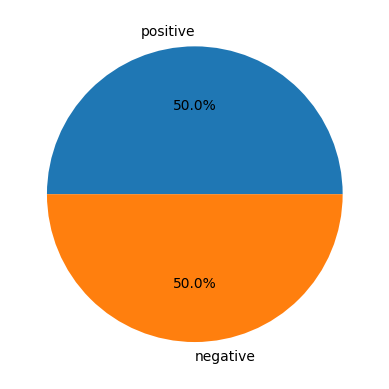

In [4]:
import matplotlib.pyplot as plt
plt.pie(counts,labels=["positive","negative"],autopct= "%1.1f%%")


In [5]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
49995,False
49996,False
49997,False
49998,False


In [6]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [7]:
df["clean_review"] = df["review"].apply(clean_text)

In [8]:
print(df[["review","clean_review"]].head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        clean_review  
0  one of the other reviewers has mentioned that ...  
1  a wonderful little production the filming tech...  
2  i thought this was a wonderful way to spend ti...  
3  basically theres a family where a little boy j...  
4  petter matteis love in the time of money is a ...  


In [9]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")

stop_words = set(stopwords.words("english"))

def tokenize_remove_stopwords(text):

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["clean_review"] = df["clean_review"].apply(tokenize_remove_stopwords)

print(df[["review", "clean_review"]].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        clean_review  
0  one reviewers mentioned watching oz episode yo...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
3  basically theres family little boy jake thinks...  
4  petter matteis love time money visually stunni...  


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer


vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_review"])
y = df["sentiment"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 40000
Testing samples: 10000


In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report


model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8495
              precision    recall  f1-score   support

    negative       0.85      0.85      0.85      4961
    positive       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [13]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Convert sparse TF-IDF matrices to dense arrays
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

# Reshape for LSTM: (samples, timesteps, features)
# Here, we treat each TF-IDF vector as a single timestep
X_train_lstm = np.expand_dims(X_train_dense, axis=1)
X_test_lstm = np.expand_dims(X_test_dense, axis=1)

# Encode target variable 'sentiment' to numerical labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Shape of X_train_lstm:", X_train_lstm.shape)
print("Shape of X_test_lstm:", X_test_lstm.shape)
print("Labels mapping:", list(label_encoder.classes_), list(label_encoder.transform(label_encoder.classes_)))


Shape of X_train_lstm: (40000, 1, 5000)
Shape of X_test_lstm: (10000, 1, 5000)
Labels mapping: ['negative', 'positive'] [np.int64(0), np.int64(1)]


### Building and Training the LSTM Model

I will now define a simple LSTM model using Keras, compile it, and train it on the prepared data.

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Define the LSTM model
model_lstm = Sequential([
    LSTM(128, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Display model summary
model_lstm.summary()

# Train the model with early stopping
history = model_lstm.fit(X_train_lstm, y_train_encoded, epochs=10, batch_size=64, validation_split=0.2, callbacks=[early_stopping])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 128)            │     2,626,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,626,177 (10.02 MB)

 Trainable params: 2,626,177 (10.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step - accuracy: 0.8571 - loss: 0.3757 - val_accuracy: 0.8854 - val_loss: 0.2725
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 68ms/step - accuracy: 0.9062 - loss: 0.2302 - val_accuracy: 0.8805 - val_loss: 0.2865
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - accuracy: 0.9178 - loss: 0.2084 - val_accuracy: 0.8745 - val_loss: 0.3043
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 69ms/step - accuracy: 0.9219 - loss: 0.1973 - val_accuracy: 0.8710 - val_loss: 0.3180


In [20]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test set
y_pred_proba_lstm = model_lstm.predict(X_test_lstm)
y_pred_lstm = (y_pred_proba_lstm > 0.5).astype(int)

# Evaluate the model
accuracy_lstm = accuracy_score(y_test_encoded, y_pred_lstm)
print(f"LSTM Model Accuracy: {accuracy_lstm:.4f}")
print("\nClassification Report for LSTM Model:\n")
print(classification_report(y_test_encoded, y_pred_lstm, target_names=label_encoder.classes_))


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
LSTM Model Accuracy: 0.8852

Classification Report for LSTM Model:

              precision    recall  f1-score   support

    negative       0.90      0.87      0.88      4961
    positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



### Comparison of Model Accuracies

In [21]:
print(f"Naive Bayes Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"LSTM Model Accuracy: {accuracy_lstm:.4f}")


Naive Bayes Model Accuracy: 0.8495
LSTM Model Accuracy: 0.8852


/tmp/ipykernel_2336/1212973727.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')


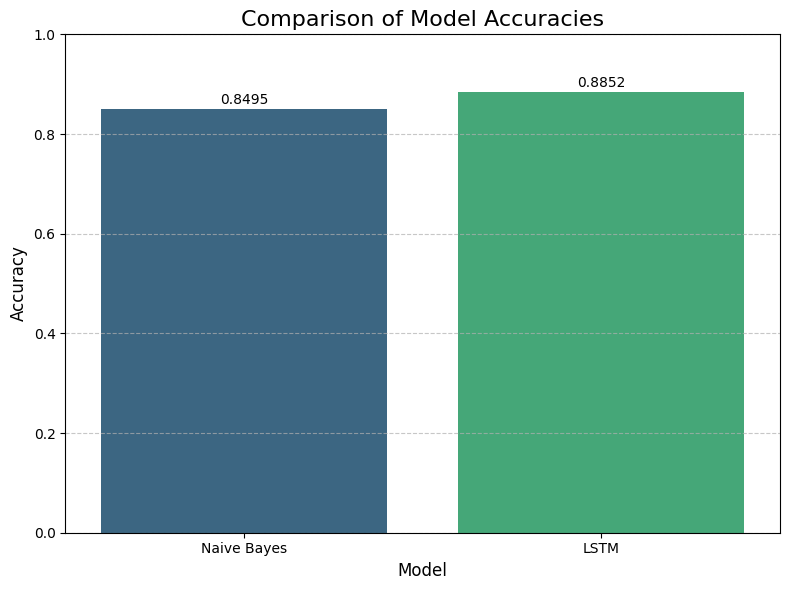

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
model_names = ['Naive Bayes', 'LSTM']
accuracies = [accuracy_score(y_test, y_pred), accuracy_lstm]

accuracy_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
})

# Create the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')

# Add labels and title
plt.title('Comparison of Model Accuracies', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1) # Accuracy is between 0 and 1

# Add accuracy values on top of the bars
for index, row in accuracy_df.iterrows():
    plt.text(index, row['Accuracy'] + 0.01, f'{row['Accuracy']:.4f}', color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Project Overview

This project focuses on building and comparing two machine learning models – Multinomial Naive Bayes and Long Short-Term Memory (LSTM) – for sentiment analysis on a dataset of 50,000 movie reviews. The goal is to classify reviews as either positive or negative.

### Dataset

The dataset used is the "IMDB Dataset of 50k Movie Reviews" from KaggleHub. It contains 50,000 movie reviews, each labeled with a sentiment (positive or negative).

### Data Preprocessing

1.  **Loading Data**: The dataset was loaded using `kagglehub` and `pandas`.
2.  **Sentiment Distribution**: The dataset has an equal distribution of positive (50%) and negative (50%) reviews.
3.  **Text Cleaning (`clean_text` function)**:
    *   Converted text to lowercase.
    *   Removed HTML tags.
    *   Removed non-alphabetic characters.
    *   Removed extra spaces.
4.  **Tokenization and Stop Word Removal (`tokenize_remove_stopwords` function)**:
    *   Tokenized the cleaned text into individual words using NLTK's `word_tokenize`.
    *   Removed common English stop words.

### Feature Extraction

*   **TF-IDF Vectorization**: The `TfidfVectorizer` from `sklearn.feature_extraction.text` was used to convert the preprocessed text into numerical feature vectors. A `max_features` limit of 5000 was applied.

### Model Training and Evaluation

The data was split into 80% training and 20% testing sets.

#### 1. Multinomial Naive Bayes Classifier

*   **Model**: `MultinomialNB` from `sklearn.naive_bayes`.
*   **Training**: Trained on the TF-IDF features of the training set.
*   **Evaluation**: Predicted sentiment on the test set.
*   **Accuracy**: `0.8495`

#### 2. Long Short-Term Memory (LSTM) Neural Network

*   **Data Preparation for LSTM**: TF-IDF sparse matrices were converted to dense numpy arrays and reshaped to `(samples, timesteps, features)` for LSTM input. Sentiment labels were encoded to numerical values (0 for negative, 1 for positive).
*   **Model Architecture**: A simple Sequential Keras model with one LSTM layer (128 units) followed by a Dense layer (1 unit) with a sigmoid activation for binary classification.
*   **Compilation**: Compiled with `adam` optimizer and `binary_crossentropy` loss.
*   **Training**: Trained with `EarlyStopping` (patience=3) to prevent overfitting, monitoring `val_loss`.
*   **Accuracy**: `0.8852`

### Model Comparison

An LSTM model achieved higher accuracy (0.8852) compared to the Naive Bayes model (0.8495) on this sentiment analysis task.

```python
# Accuracy Comparison
# Naive Bayes Model Accuracy: 0.8495
# LSTM Model Accuracy: 0.8852
```

### Future Improvements

To further improve the accuracy of the LSTM model, consider:

*   **Using Word Embeddings**: Replace TF-IDF with pre-trained word embeddings like Word2Vec, GloVe, or FastText to capture semantic meaning and context.
*   **Bidirectional LSTMs (BiLSTMs)**: Process sequences in both directions for richer context understanding.
*   **Adding Dropout Layers**: Further regularize the model to prevent overfitting.
*   **Hyperparameter Tuning**: Optimize learning rate, batch size, and other model parameters.
*   **Transfer Learning**: Fine-tune state-of-the-art transformer models like BERT for potentially much higher accuracy.

### Usage

This notebook can be run in a Python environment with the following libraries installed:

*   `kagglehub`
*   `pandas`
*   `nltk`
*   `scikit-learn`
*   `tensorflow` (for Keras)
*   `matplotlib`
*   `seaborn`

Alternatively, you can run this notebook directly in Google Colab.